# 01 — Core results: H1 (PnL ranking) and H2 (inventory control)

Inputs: `results/metrics/core/run_metrics.csv` (4 agents × 3 vol × 3 tox × 2 comp × 30 seeds = 2,160 runs).

Hypotheses tested in this notebook:
- **H1**: Adaptive market makers (B, C, C+) earn higher mean PnL than fixed-spread Agent A across volatility/toxicity regimes.
- **H2**: Inventory-aware agents (B, C, C+) hold smaller absolute inventory than Agent A.

Statistical tests: bootstrap 95% CIs on mean PnL and `inventory_max_abs`; Welch's t for the pairwise contrasts {A vs B, B vs C, C vs C+} within each (vol, tox) cell at `competition='with_competitor'`.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "pyproject.toml").exists() or (cand / "src/lob_market_making_agents").exists():
            return cand
    return here

REPO_ROOT = _find_repo_root()
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from lob_market_making_agents.analysis.plots import (
    AGENT_ORDER,
    TOX_ORDER,
    VOL_ORDER,
    agent_palette,
    bootstrap_ci,
    order_categorical,
    save_figure,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 144, "axes.grid": True, "grid.alpha": 0.3})

CORE_CSV = REPO_ROOT / "results/metrics/core/run_metrics.csv"
FIG_DIR = REPO_ROOT / "results/figures/core"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(CORE_CSV)
print("rows:", len(df))
assert len(df) == 2160, f"expected 2160 rows, got {len(df)}"
assert sorted(df.agent.unique()) == sorted(AGENT_ORDER)
counts = df.groupby(["agent", "volatility", "toxicity", "competition"]).size()
assert (counts == 30).all(), "expected 30 seeds per condition"
df.head()

rows: 2160


,run_id,config_name,agent,volatility,toxicity,competition,seed,steps,fills,fill_rate,...,final_pnl,pnl_per_step,inventory_mean,inventory_var,inventory_max_abs,inventory_exposure_frac_abs_gt_threshold,markout_mean_h5,markout_std_h5,markout_p5_h5,markout_count_h5
0,mvp_bse_first_A_high_tox0_solo_s11_9aee4dcc1f,mvp_bse_first,A,high,0.0,solo,11,5000.0,3492.0,0.6984,...,-982.000000,-0.196400,-40.1272,457.057820,84.0,0.9898,1.017191,2.713463,-3.472166,3490.0
1,mvp_bse_first_A_high_tox0_solo_s13_c7648076f6,mvp_bse_first,A,high,0.0,solo,13,5000.0,3517.0,0.7034,...,4866.215089,0.973243,-30.6640,1047.727504,95.0,0.8436,1.027089,2.719047,-3.232281,3513.0
2,mvp_bse_first_A_high_tox0_solo_s17_c6ebc91372,mvp_bse_first,A,high,0.0,solo,17,5000.0,3543.0,0.7086,...,3931.000000,0.786200,-39.4780,897.410716,89.0,0.9046,1.002625,2.707692,-3.354977,3540.0
3,mvp_bse_first_A_high_tox0_solo_s19_0910891aa4,mvp_bse_first,A,high,0.0,solo,19,5000.0,3451.0,0.6902,...,3051.608050,0.610322,40.7086,247.967686,70.0,0.9904,1.024397,2.690465,-3.347941,3446.0
4,mvp_bse_first_A_high_tox0_solo_s23_3f07b1a40d,mvp_bse_first,A,high,0.0,solo,23,5000.0,3489.0,0.6978,...,7138.159033,1.427632,-38.8940,645.820364,85.0,0.9362,0.938055,2.712688,-3.569044,3485.0


## PnL distribution (boxplots faceted by vol × tox)

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/pnl_box_solo.png


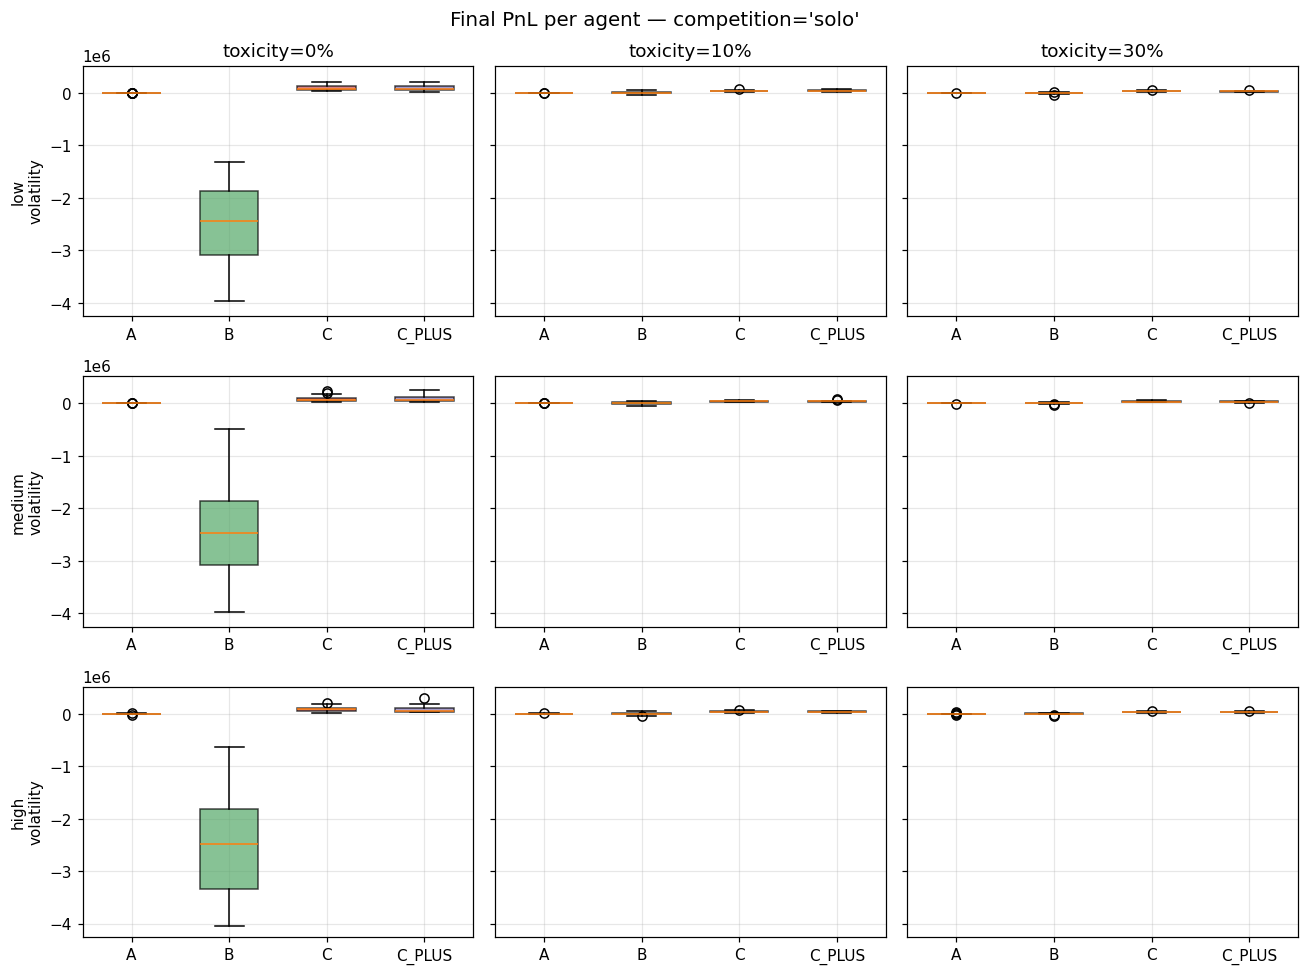

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/pnl_box_with_competitor.png


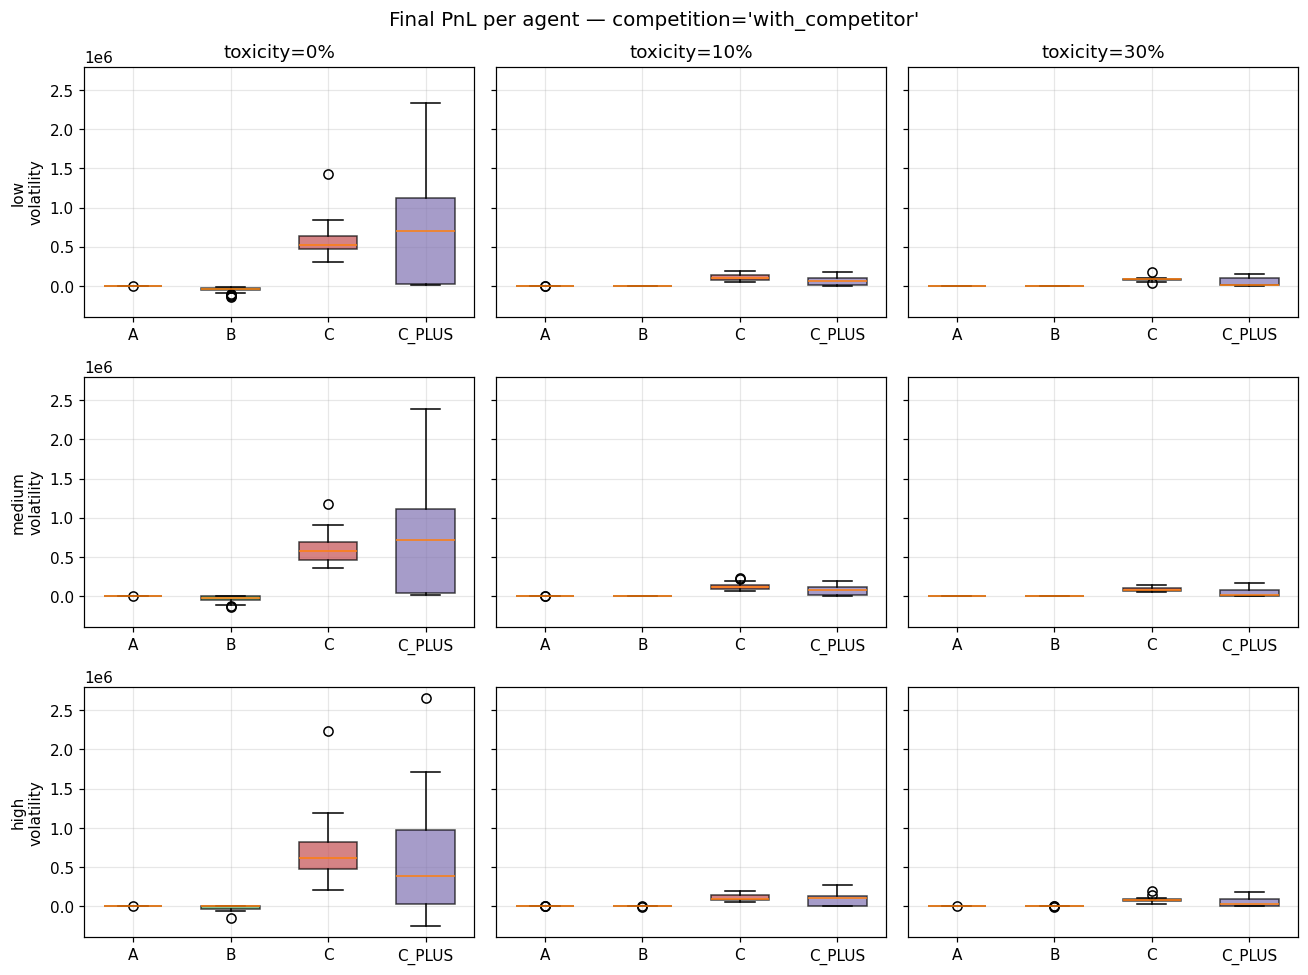

In [3]:
def boxplot_grid(values_col: str, ylabel: str, comp_value: str, fname: str):
    df_c = df[df.competition == comp_value]
    fig, axes = plt.subplots(len(VOL_ORDER), len(TOX_ORDER), figsize=(12, 9), sharey=True)
    palette = agent_palette()
    for i, vol in enumerate(VOL_ORDER):
        for j, tox in enumerate(TOX_ORDER):
            ax = axes[i, j]
            cell = df_c[(df_c.volatility == vol) & (df_c.toxicity == tox)]
            data = [cell[cell.agent == a][values_col].values for a in AGENT_ORDER]
            bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
            for patch, agent in zip(bp["boxes"], AGENT_ORDER):
                patch.set_facecolor(palette[agent])
                patch.set_alpha(0.7)
            if i == 0:
                ax.set_title(f"toxicity={int(tox)}%")
            if j == 0:
                ax.set_ylabel(f"{vol}\nvolatility")
    fig.suptitle(f"{ylabel} per agent — competition='{comp_value}'", fontsize=13)
    out = FIG_DIR / fname
    save_figure(fig, out)
    print("wrote", out)
    plt.show()


for comp in ("solo", "with_competitor"):
    boxplot_grid("final_pnl", "Final PnL", comp, f"pnl_box_{comp}.png")

## Inventory exposure

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/inventory_max_abs_box_solo.png


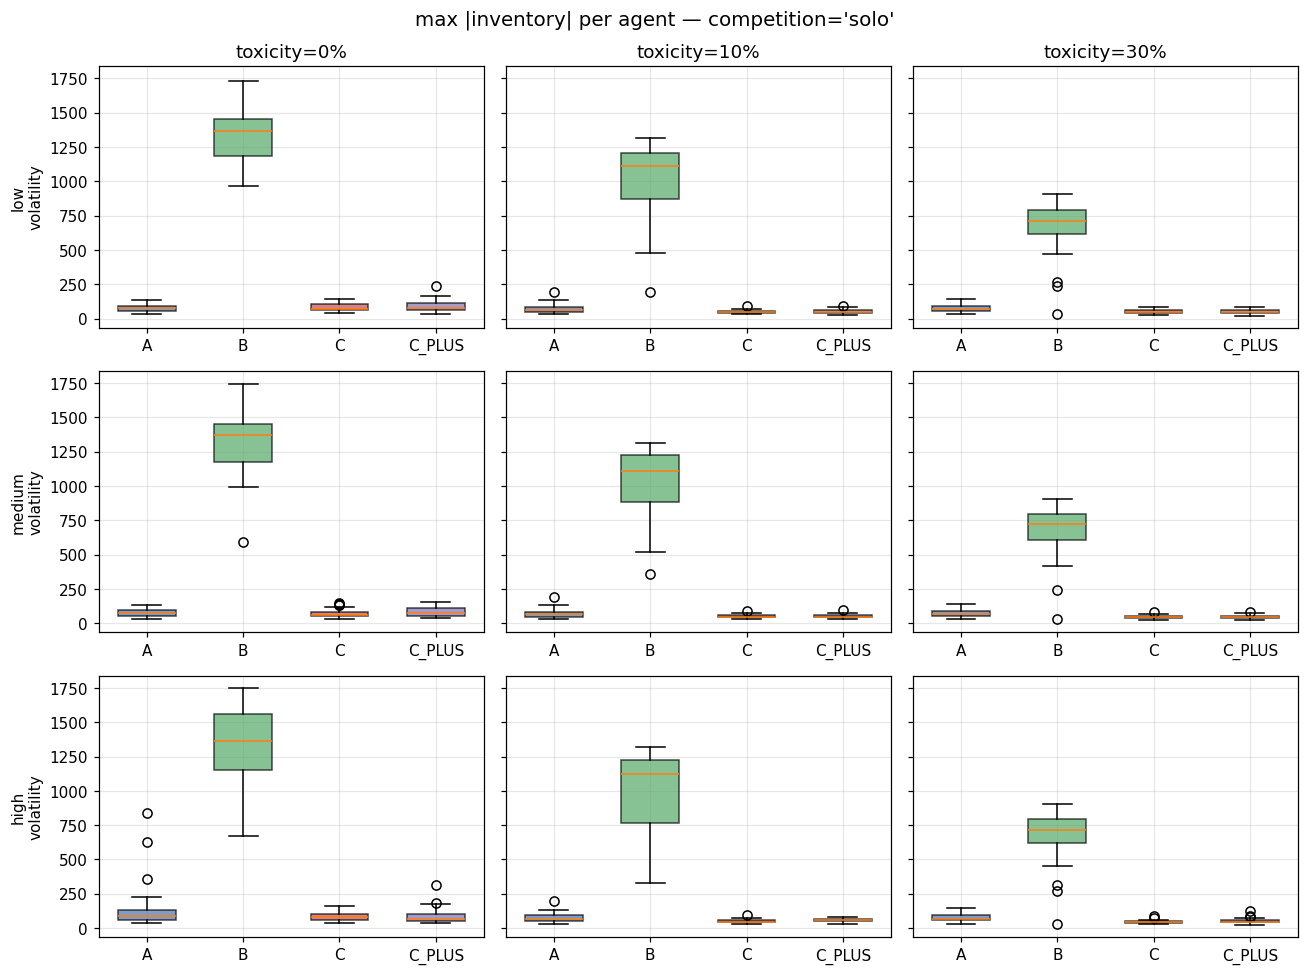

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/inventory_exposure_box_solo.png


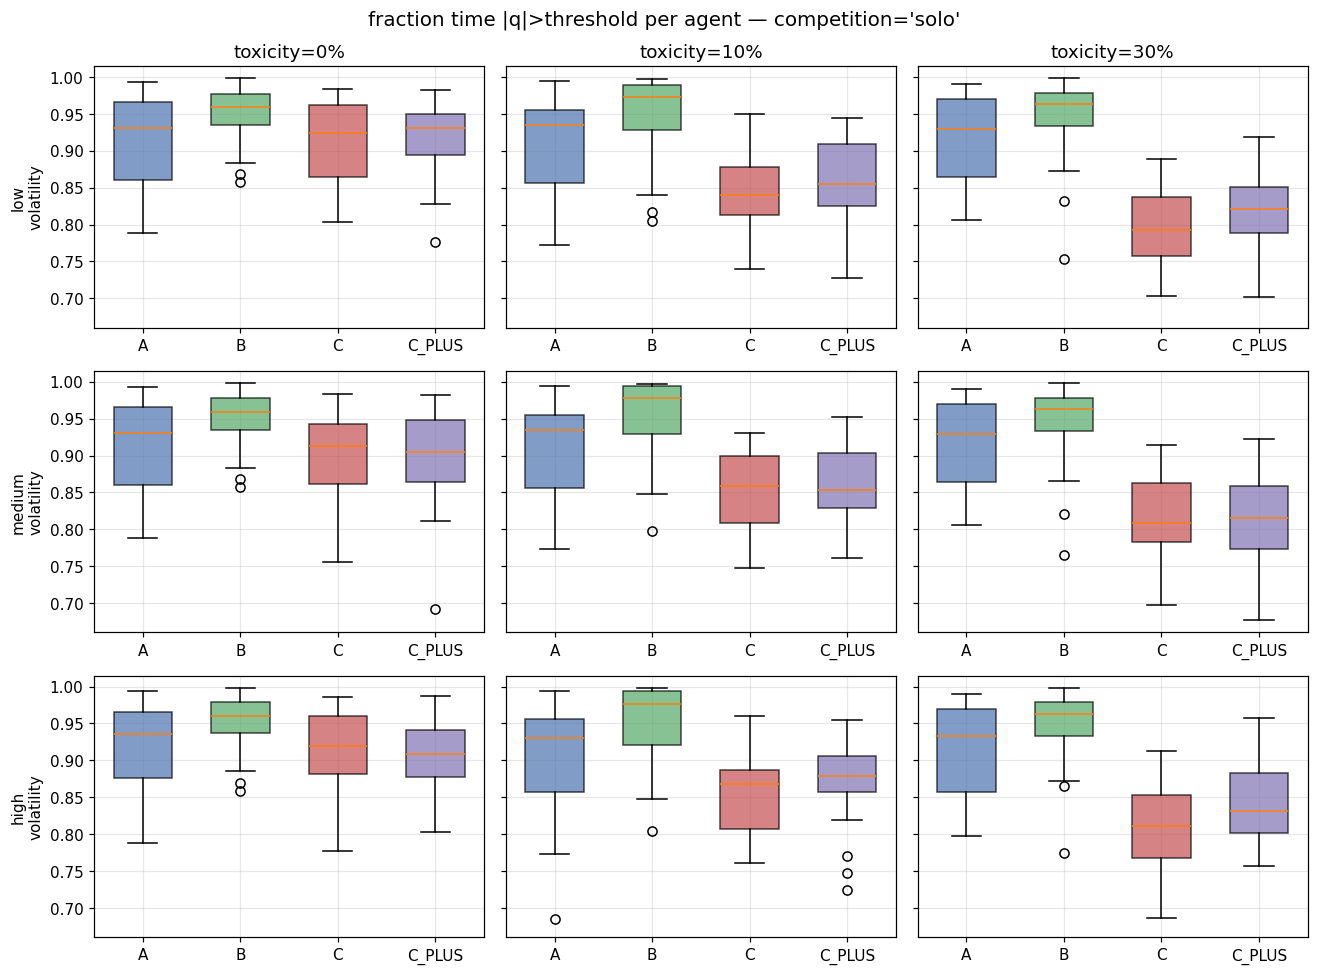

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/inventory_max_abs_box_with_competitor.png


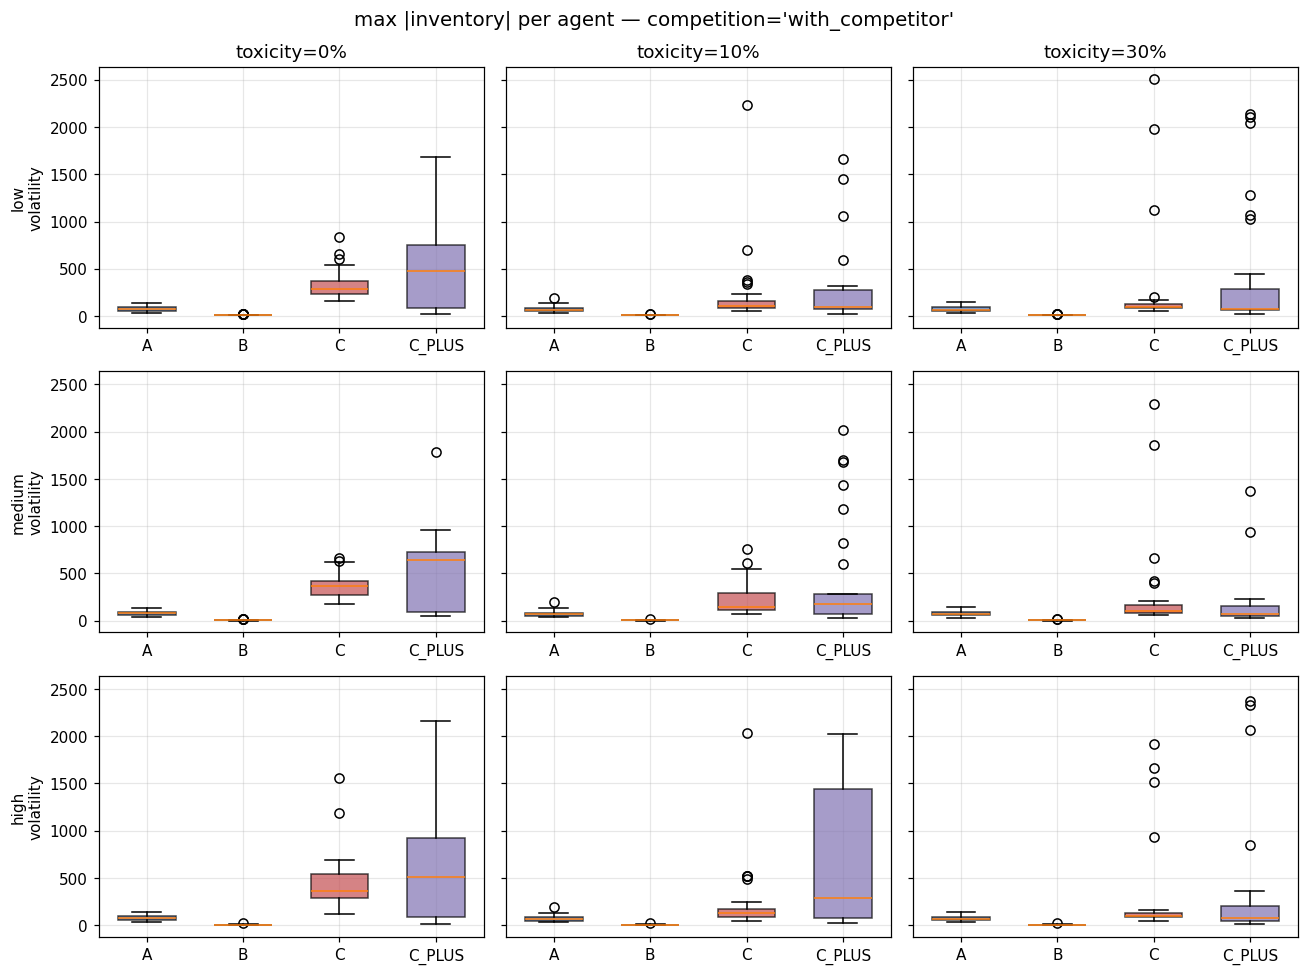

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_77127/4098845002.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(AGENT_ORDER), patch_artist=True, widths=0.6)
/

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/figures/core/inventory_exposure_box_with_competitor.png


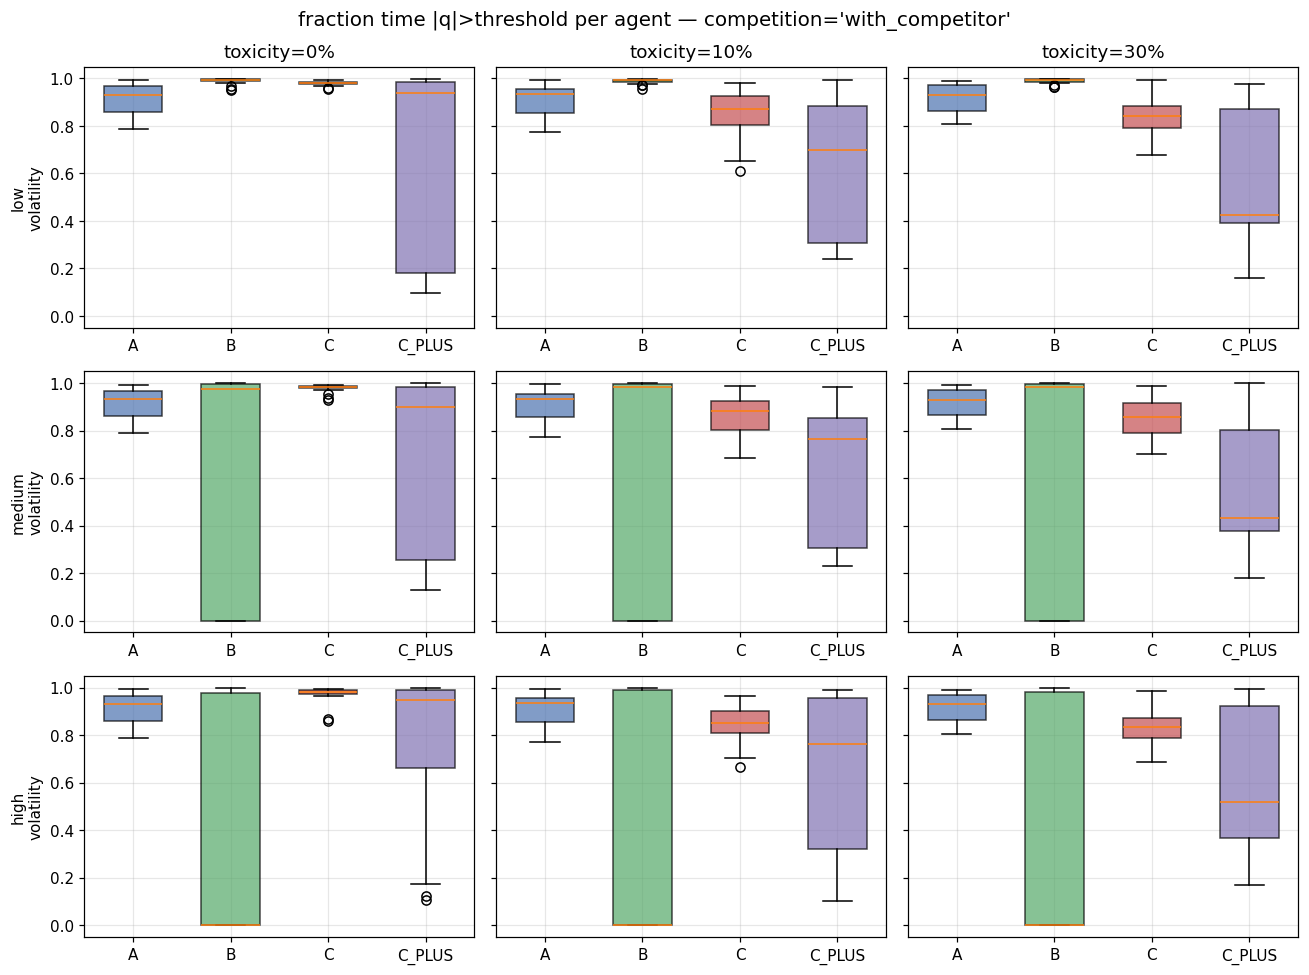

In [4]:
for comp in ("solo", "with_competitor"):
    boxplot_grid("inventory_max_abs", "max |inventory|", comp, f"inventory_max_abs_box_{comp}.png")
    boxplot_grid("inventory_exposure_frac_abs_gt_threshold", "fraction time |q|>threshold", comp, f"inventory_exposure_box_{comp}.png")

## Markout (h=5) — adverse-selection signal

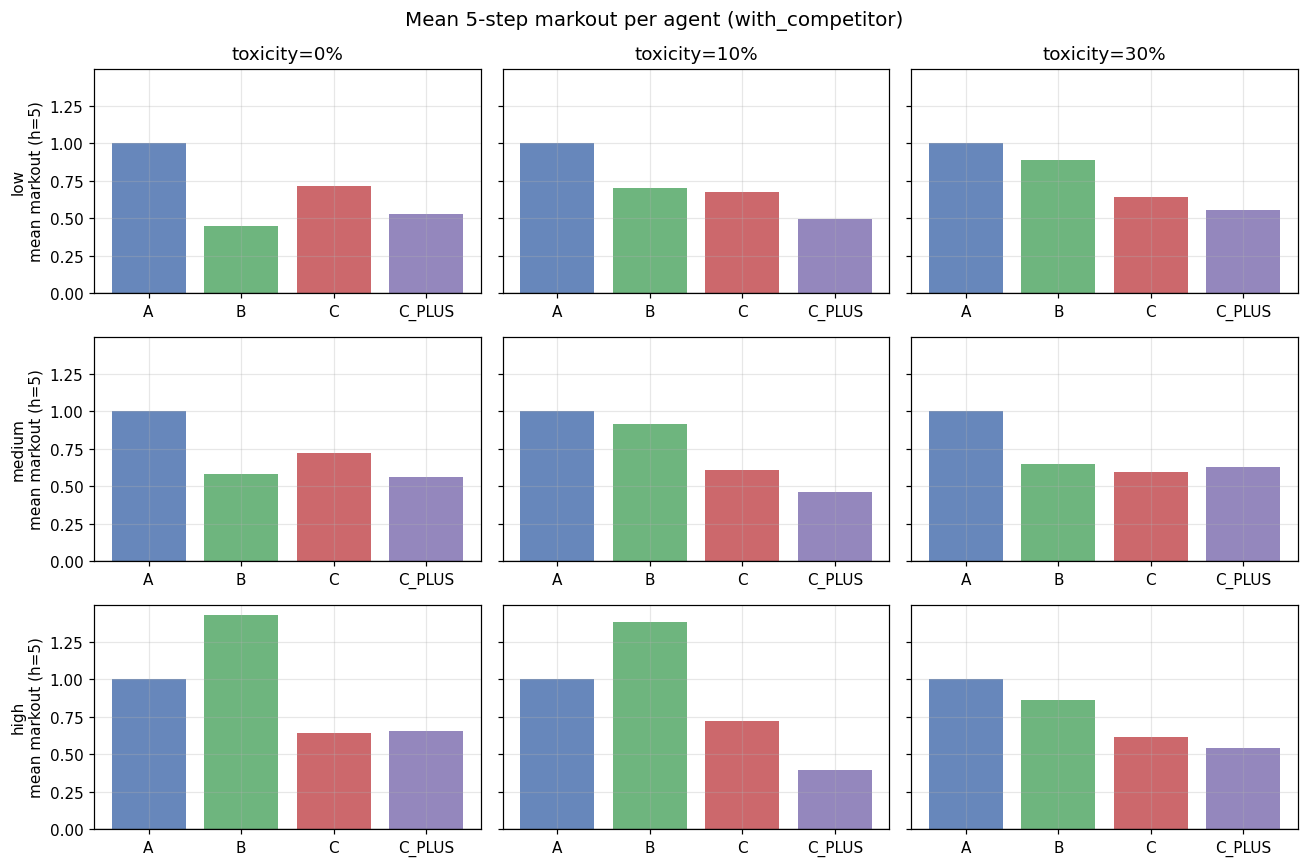

In [5]:
fig, axes = plt.subplots(len(VOL_ORDER), len(TOX_ORDER), figsize=(12, 8), sharey=True)
palette = agent_palette()
for i, vol in enumerate(VOL_ORDER):
    for j, tox in enumerate(TOX_ORDER):
        ax = axes[i, j]
        cell = df[(df.competition == "with_competitor") & (df.volatility == vol) & (df.toxicity == tox)]
        means = [cell[cell.agent == a].markout_mean_h5.mean() for a in AGENT_ORDER]
        ax.bar(list(AGENT_ORDER), means, color=[palette[a] for a in AGENT_ORDER], alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.8)
        if i == 0:
            ax.set_title(f"toxicity={int(tox)}%")
        if j == 0:
            ax.set_ylabel(f"{vol}\nmean markout (h=5)")
fig.suptitle("Mean 5-step markout per agent (with_competitor)", fontsize=13)
save_figure(fig, FIG_DIR / "markout_h5.png")
plt.show()

## Bootstrap 95% CIs on mean PnL and `inventory_max_abs`

In [6]:
records = []
for (agent, vol, tox, comp), cell in df.groupby(["agent", "volatility", "toxicity", "competition"]):
    pnl_mean, pnl_lo, pnl_hi = bootstrap_ci(cell.final_pnl.values, seed=hash((agent, vol, tox, comp)) & 0xFFFF)
    inv_mean, inv_lo, inv_hi = bootstrap_ci(cell.inventory_max_abs.values, seed=(hash((agent, vol, tox, comp, "i"))) & 0xFFFF)
    records.append({
        "agent": agent, "volatility": vol, "toxicity": tox, "competition": comp,
        "pnl_mean": pnl_mean, "pnl_lo": pnl_lo, "pnl_hi": pnl_hi,
        "inv_max_mean": inv_mean, "inv_max_lo": inv_lo, "inv_max_hi": inv_hi,
    })
ci = pd.DataFrame.from_records(records)
ci = order_categorical(ci, "agent", AGENT_ORDER)
ci = order_categorical(ci, "volatility", VOL_ORDER)
out_csv = REPO_ROOT / "results/metrics/core/ci_table.csv"
ci.to_csv(out_csv, index=False)
print("wrote", out_csv)
ci.head(12).round(3)

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/metrics/core/ci_table.csv


,agent,volatility,toxicity,competition,pnl_mean,pnl_lo,pnl_hi,inv_max_mean,inv_max_lo,inv_max_hi
6,A,low,0.0,solo,3256.135,2925.062,3548.518,77.533,67.699,86.968
7,A,low,0.0,with_competitor,3496.633,3486.798,3505.767,77.533,68.399,87.201
8,A,low,10.0,solo,3144.731,2767.806,3500.991,71.667,60.533,84.867
9,A,low,10.0,with_competitor,3499.633,3487.332,3511.968,71.667,60.599,84.401
10,A,low,30.0,solo,2699.886,2183.992,3202.456,76.700,66.797,87.601
11,A,low,30.0,with_competitor,3495.300,3484.133,3506.409,76.700,66.666,87.503
24,B,low,0.0,solo,-2545494.628,-2840062.701,-2258631.783,1341.100,1265.490,1422.002
25,B,low,0.0,with_competitor,-49003.267,-61634.820,-37381.283,9.633,8.000,11.533
26,B,low,10.0,solo,6900.531,-1740.701,15501.844,1003.100,906.265,1093.955
27,B,low,10.0,with_competitor,-1905.650,-2320.181,-1547.130,8.100,7.233,9.300


## Pairwise Welch t-tests (with_competitor)

In [7]:
contrasts = [("A", "B"), ("B", "C"), ("C", "C_PLUS")]
records = []
df_comp = df[df.competition == "with_competitor"]
for vol in VOL_ORDER:
    for tox in TOX_ORDER:
        cell = df_comp[(df_comp.volatility == vol) & (df_comp.toxicity == tox)]
        for a, b in contrasts:
            xs = cell[cell.agent == a].final_pnl.values
            ys = cell[cell.agent == b].final_pnl.values
            t = stats.ttest_ind(xs, ys, equal_var=False)
            records.append({
                "volatility": vol, "toxicity": tox, "contrast": f"{a}_vs_{b}",
                "mean_diff": ys.mean() - xs.mean(), "t_stat": t.statistic, "p_value": t.pvalue,
            })
tests = pd.DataFrame.from_records(records)
out_csv = REPO_ROOT / "results/metrics/core/pairwise_tests.csv"
tests.to_csv(out_csv, index=False)
print("wrote", out_csv)
tests.round(4)

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/metrics/core/pairwise_tests.csv


,volatility,toxicity,contrast,mean_diff,t_stat,p_value
0,low,0.0,A_vs_B,-52499.9000,8.2454,0.0000
1,low,0.0,B_vs_C,615441.3905,-15.6731,0.0000
2,low,0.0,C_vs_C_PLUS,195614.9270,-1.3158,0.1972
3,low,10.0,A_vs_B,-5405.2833,26.6229,0.0000
4,low,10.0,B_vs_C,108839.5500,-13.9415,0.0000
5,low,10.0,C_vs_C_PLUS,-40821.2786,3.1121,0.0030
6,low,30.0,A_vs_B,-5121.7000,27.0704,0.0000
7,low,30.0,B_vs_C,85541.4729,-20.3810,0.0000
8,low,30.0,C_vs_C_PLUS,-33425.6592,2.9896,0.0049
9,medium,0.0,A_vs_B,-39538.8500,5.6065,0.0000


## Notes for the report
- The two PnL boxplot figures and the markout bar chart cover H1.
- The two inventory-exposure figures cover H2.
- `ci_table.csv` and `pairwise_tests.csv` provide the numerical backing for results-section claims.